# S6 Discrete Approximation
3C6 Section 6: lumped mass string model

## imports and definitions

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
matplotlib.rcParams.update({'font.size': 12,'font.family':'serif'})

from ipywidgets import interact,widgets,Layout

In [2]:
%matplotlib widget

## Setup properties

interactive(children=(IntSlider(value=3, description='N', layout=Layout(width='800px'), min=3), Output()), _do…

<function __main__.compare(N)>

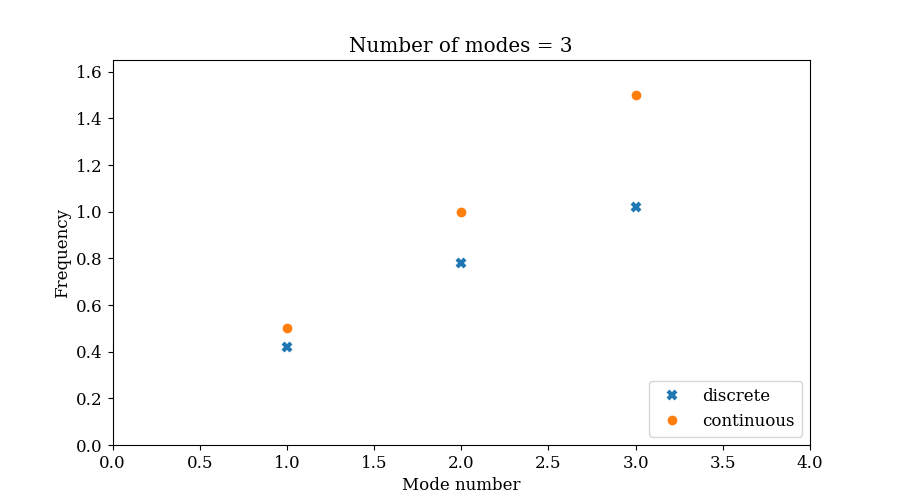

In [3]:
# Parameters
L = 1 # total length
P = 1 # tension
M = 1 # total mass


plt.figure(figsize=(9,5),dpi=100)
L1 = plt.plot(0,0,'x',label='discrete',markeredgewidth=3)
L2 = plt.plot(0,0,'o',label='continuous')
plt.legend(loc='lower right')
plt.xlabel('Mode number')
plt.ylabel('Frequency')


def compare(N):
    # Mass and stiffness matrices
    m = M/N # discrete mass
    MM = m * np.eye(N)
    KK = np.zeros((N,N))
    KK += np.diag(2*np.ones(N))
    KK += np.diag(-1*np.ones(N-1),k=-1)
    KK += np.diag(-1*np.ones(N-1),k=1)
    KK = P/(L/(N+1)) * KK

    # Natural frequencies
    n = 1+np.arange(N)
    f_continuous = 1/2/np.pi * n*np.pi/L * np.sqrt(P/(M/L))

    D,V = la.eigh(KK,MM)
    f_discrete = 1/2/np.pi * np.sqrt(D)

    f_c_ratios = f_continuous/f_continuous[0]
    f_d_ratios = f_discrete/f_discrete[0]
    
    L1[0].set_xdata(n)
    L1[0].set_ydata(f_discrete)
    L2[0].set_xdata(n)
    L2[0].set_ydata(f_continuous)
    plt.xlim([0,N+1])
    plt.ylim([0,1.1*f_continuous[-1]])
    plt.title("Number of modes = {}".format(N))
    plt.draw()
    
interact(compare,N=widgets.IntSlider(min=3, max=100, step=1, value=3,layout=Layout(width='800px')))